# Inverse Problem: PINNs for Bathymetry Calibration

This notebook now focuses only on the original inverse PINN practical.
The objective is to estimate the unknown spatially distributed `K_s` field from water-height observations while enforcing the backwater PDE.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch

import display
from Backwater_model import Ks_function, compute_ref_solution
from normalization import normalize_input
from PINN import PINN
from trainer import PITrainer

def default_device(use_gpu=True):
    if torch.cuda.is_available() and use_gpu:
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    torch.set_default_device(device)
    return device

def default_problem(device, seed=0):
    del seed
    k_true = torch.tensor([45, 38, 28, 22, 30, 45, 60, 75], device=device)
    collocation_points = torch.linspace(0, 1000, 100, device=device).view(-1, 1)
    collocation_points.requires_grad_(True)
    return k_true, collocation_points

def build_observations(ref_solution, n_obs, seed=None, noise_std=0, grid=True):
    if seed is not None:
        torch.manual_seed(seed)
    device = ref_solution["domain"].device
    n_domain = ref_solution["domain"].shape[0]
    if n_obs == 0:
        return torch.empty((0, 2), device=device)
    if grid:
        indices = torch.linspace(0, n_domain - 1, steps=n_obs, device=device).long()
    else:
        indices = torch.randperm(n_domain, device=device)[:n_obs]
    noisy_solution = ref_solution["solution"].detach().clone() + torch.randn(n_domain, 1, device=device) * noise_std
    return torch.hstack((ref_solution["domain"], noisy_solution))[indices].detach().clone()

def build_pinn(device, k_true, seed=0, k_ref=1.0, trainable_k=False):
    return PINN(
        device=device,
        layer_sizes=[1, 40, 1],
        initial_k=k_true,
        k_ref=k_ref,
        seed=seed,
        trainable_k=trainable_k,
    )

def print_parameter_count(model, name="Model"):
    print(
        f"{name} parameter count: total={sum(parameter.numel() for parameter in model.parameters()):,}, "
        f"trainable={sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad):,}"
    )

print('Pytorch version:', torch.__version__)

Pytorch version: 2.11.0


## Setup

We use the same 8-parameter `K_s` representation as in the original inverse practical.

Running on cpu!


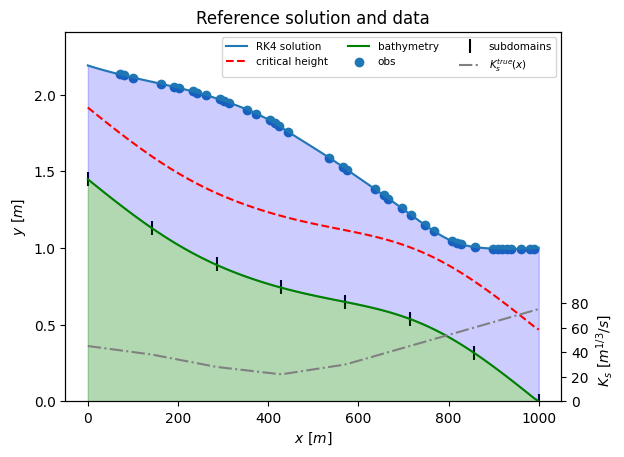

In [2]:
device = default_device(use_gpu=True)
print(f"Running on {device}!")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

k_true, col = default_problem(device, seed=0)
reference_model = build_pinn(device, k_true, seed=0)
print_parameter_count(reference_model, "reference_model")
ref_solution = compute_ref_solution(col, k=k_true, dx=10)

obs = build_observations(ref_solution, n_obs=40, seed=0, grid=False)
display.display_data(reference_model, col, ref_solution, obs)

## PINN Inverse Calibration

This reproduces the original PP1 workflow: pre-training on observations, then alternating optimization on the network weights and on `K_s`.

##################################################
Processing evaluation 50
-------------------------
J           = 2.15e-02 (residual : 0.00e+00, obs : 2.07e-02, BC : 7.80e-04)
||grad(J)|| = 5.15e-02
parameter    = tensor([40., 40., 40., 40., 40., 40., 40., 40.])
time         = 0.84 s
##################################################
Processing evaluation 100
-------------------------
J           = 1.24e-04 (residual : 0.00e+00, obs : 1.24e-04, BC : 3.64e-07)
||grad(J)|| = 7.54e-03
parameter    = tensor([40., 40., 40., 40., 40., 40., 40., 40.])
time         = 0.95 s
##################################################
Processing evaluation 150
-------------------------
J           = 9.98e-05 (residual : 5.22e-06, obs : 9.45e-05, BC : 1.35e-07)
||grad(J)|| = 5.43e-04
parameter    = tensor([48.6161, 35.7188, 28.9037, 22.2472, 27.6523, 48.2769, 57.4235, 50.8824])
time         = 1.07 s
##################################################
Processing evaluation 200
-------------------------
J 

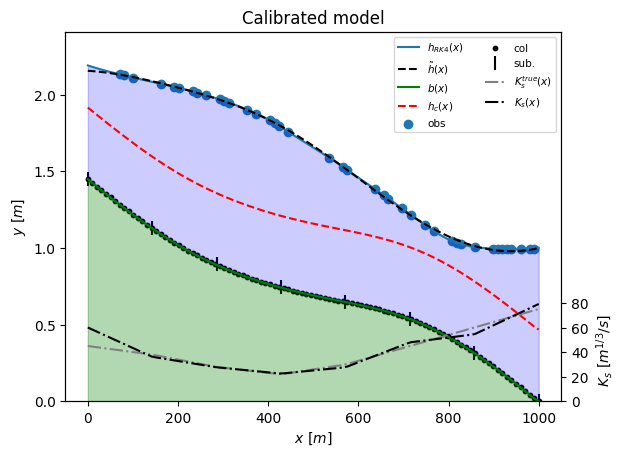

In [3]:
# Step 1: build the model.
pinn_inverse = build_pinn(
    device,
    40 * torch.ones_like(k_true),
    seed=0,
    k_ref=40,
    trainable_k=True,
)
print_parameter_count(pinn_inverse, "pinn_inverse")
pinn_inverse_trainer = PITrainer(train_k=True)
# Step 2: train the model.
pinn_inverse_result = pinn_inverse_trainer.fit(
    pinn_inverse,
    col,
    obs,
    ref_solution,
    pre_train_iter=100,
    alter_steps=4,
    alter_freq=(40, 10),
    scale_losses=True,
    display_freq=(50, 100),
)
# Step 3: evaluate the model.
pinn_inverse_rmse = display.display_training(pinn_inverse, col, ref_solution)
display.display_results(pinn_inverse, col, ref_solution, obs, plot_col=True)

## Compare the Recovered `K_s(x)` and `h(x)`

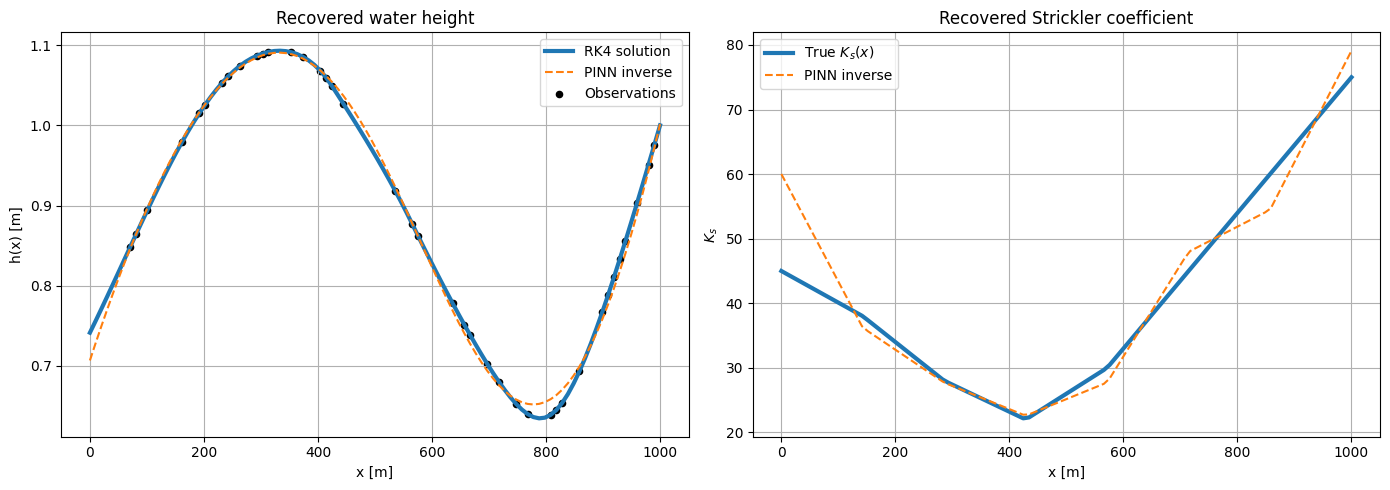

In [4]:
x = ref_solution["domain"].detach().clone().cpu().numpy().flatten()
h_true = ref_solution["solution"].detach().clone().cpu().numpy().flatten()
h_pinn = (
    pinn_inverse(normalize_input(ref_solution["domain"], col))
    .detach()
    .clone()
    .cpu()
    .numpy()
    .flatten()
)

ks_true = ref_solution["parameter_function"].detach().clone().cpu().numpy().flatten()
ks_pinn = (
    Ks_function(ref_solution["domain"], pinn_inverse.parameter_values(), col)
    .detach()
    .clone()
    .cpu()
    .numpy()
    .flatten()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x, h_true, label="RK4 solution", linewidth=3)
axes[0].plot(x, h_pinn, "--", label="PINN inverse")
axes[0].scatter(
    obs[:, 0].detach().clone().cpu().numpy(),
    obs[:, 1].detach().clone().cpu().numpy(),
    s=20,
    c="k",
    label="Observations",
)
axes[0].set_title("Recovered water height")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("h(x) [m]")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(x, ks_true, label="True $K_s(x)$", linewidth=3)
axes[1].plot(x, ks_pinn, "--", label="PINN inverse")
axes[1].set_title("Recovered Strickler coefficient")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("$K_s$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
def relative_parameter_error(estimate, truth):
    return np.linalg.norm(estimate - truth, ord=2) / np.linalg.norm(truth, ord=2)


comparison = {
    "PINN_solution_rmse": pinn_inverse_rmse,
    "PINN_parameter_error": relative_parameter_error(ks_pinn, ks_true),
}
comparison

{'PINN_solution_rmse': np.float32(0.01071041),
 'PINN_parameter_error': np.float32(0.08583365)}

## Sensitivity to the Number of Observations

The original inverse practical explicitly asks about sensitivity to hyperparameters such as `N_obs`.
The cell below evaluates that sensitivity for the PINN inverse strategy.

In [6]:
def run_inverse_case(n_obs, alter_freq, seed=0):
    model = build_pinn(
        device,
        40 * torch.ones_like(k_true),
        seed=seed,
        k_ref=40,
        trainable_k=True,
    )
    print_parameter_count(model, "model")
    local_obs = build_observations(ref_solution, n_obs=n_obs, seed=seed, grid=False)
    trainer = PITrainer(train_k=True)
    trainer.fit(
        model,
        col,
        local_obs,
        ref_solution,
        pre_train_iter=100,
        alter_steps=4,
        alter_freq=alter_freq,
        scale_losses=True,
        display_freq=(500, 500),
    )
    ks_est = (
        Ks_function(ref_solution["domain"], model.parameter_values(), col)
        .detach()
        .clone()
        .cpu()
        .numpy()
        .flatten()
    )
    h_est = (
        model(normalize_input(ref_solution["domain"], col))
        .detach()
        .clone()
        .cpu()
        .numpy()
        .flatten()
    )
    return {
        "parameter_error": relative_parameter_error(ks_est, ks_true),
        "solution_error": relative_parameter_error(h_est, h_true),
    }


n_obs_values = [10, 40, 80, 120, 160, 200]
pinn_sensitivity = {n: run_inverse_case(n, (40, 10)) for n in n_obs_values}
pinn_sensitivity

##################################################
Processing evaluation 500
-------------------------
J           = 1.77e-05 (residual : 1.60e-06, obs : 1.61e-05, BC : 1.91e-10)
||grad(J)|| = 9.85e-05
parameter    = tensor([28.5618, 30.7009, 28.8282, 22.4863, 28.1547, 48.7329, 52.7563, 64.0396])
time         = 0.91 s
##################################################
Processing evaluation 500
-------------------------
J           = 8.00e-05 (residual : 3.26e-06, obs : 7.50e-05, BC : 1.72e-06)
||grad(J)|| = 9.01e-05
parameter    = tensor([60.0129, 36.2053, 27.7092, 22.5874, 27.7340, 47.9679, 54.4702, 79.1123])
time         = 0.91 s
##################################################
Processing evaluation 500
-------------------------
J           = 8.83e-05 (residual : 3.57e-06, obs : 8.39e-05, BC : 8.83e-07)
||grad(J)|| = 1.38e-04
parameter    = tensor([50.0886, 35.8415, 28.5056, 22.2092, 27.9701, 48.3878, 54.1886, 78.6573])
time         = 0.90 s
########################################

{10: {'parameter_error': np.float32(0.14567894),
  'solution_error': np.float32(0.033868227)},
 40: {'parameter_error': np.float32(0.08583365),
  'solution_error': np.float32(0.01071041)},
 80: {'parameter_error': np.float32(0.05142662),
  'solution_error': np.float32(0.009428383)},
 120: {'parameter_error': np.float32(0.050285134),
  'solution_error': np.float32(0.008634102)},
 160: {'parameter_error': np.float32(0.050285134),
  'solution_error': np.float32(0.008634102)},
 200: {'parameter_error': np.float32(0.050285134),
  'solution_error': np.float32(0.008634102)}}

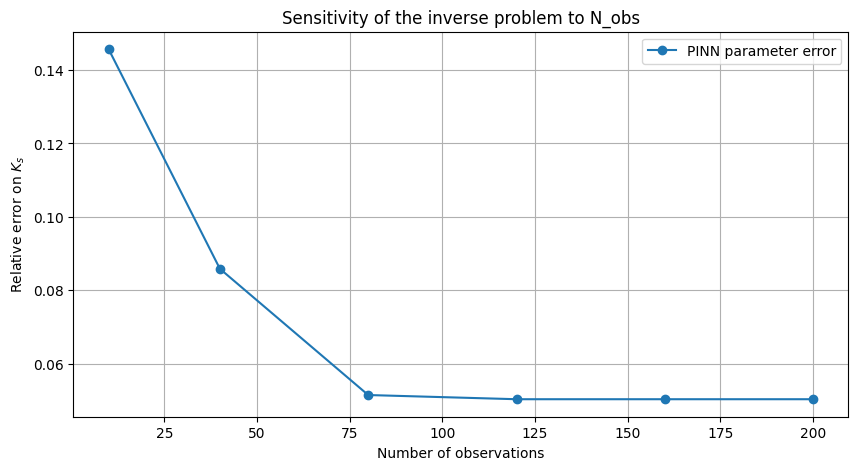

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(
    n_obs_values,
    [pinn_sensitivity[n]["parameter_error"] for n in n_obs_values],
    "o-",
    label="PINN parameter error",
)
plt.xlabel("Number of observations")
plt.ylabel("Relative error on $K_s$")
plt.title("Sensitivity of the inverse problem to N_obs")
plt.grid(True)
plt.legend()
plt.show()